In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("data/telco_churn.csv")

# First look
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data types and missing values
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22508\4130265634.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Reds_r')


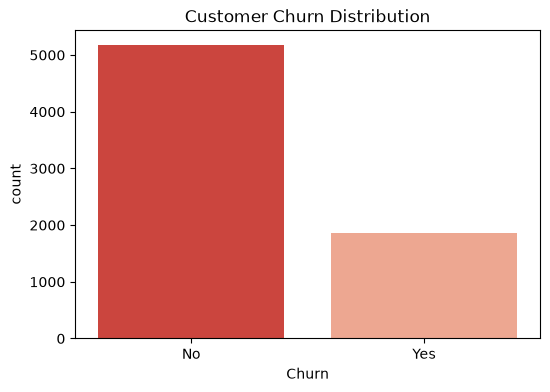

In [4]:
# How many customers churned vs stayed?
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']:.2%}")

# Visualize
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Reds_r')
plt.title("Customer Churn Distribution")
plt.show()

In [5]:
# Which columns are categorical vs numerical?
print("=== Categorical Columns ===")
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

print("\n=== Numerical Columns ===")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols)

=== Categorical Columns ===
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

=== Numerical Columns ===
['SeniorCitizen', 'tenure', 'MonthlyCharges']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22508\4067896924.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1,0], palette='coolwarm')


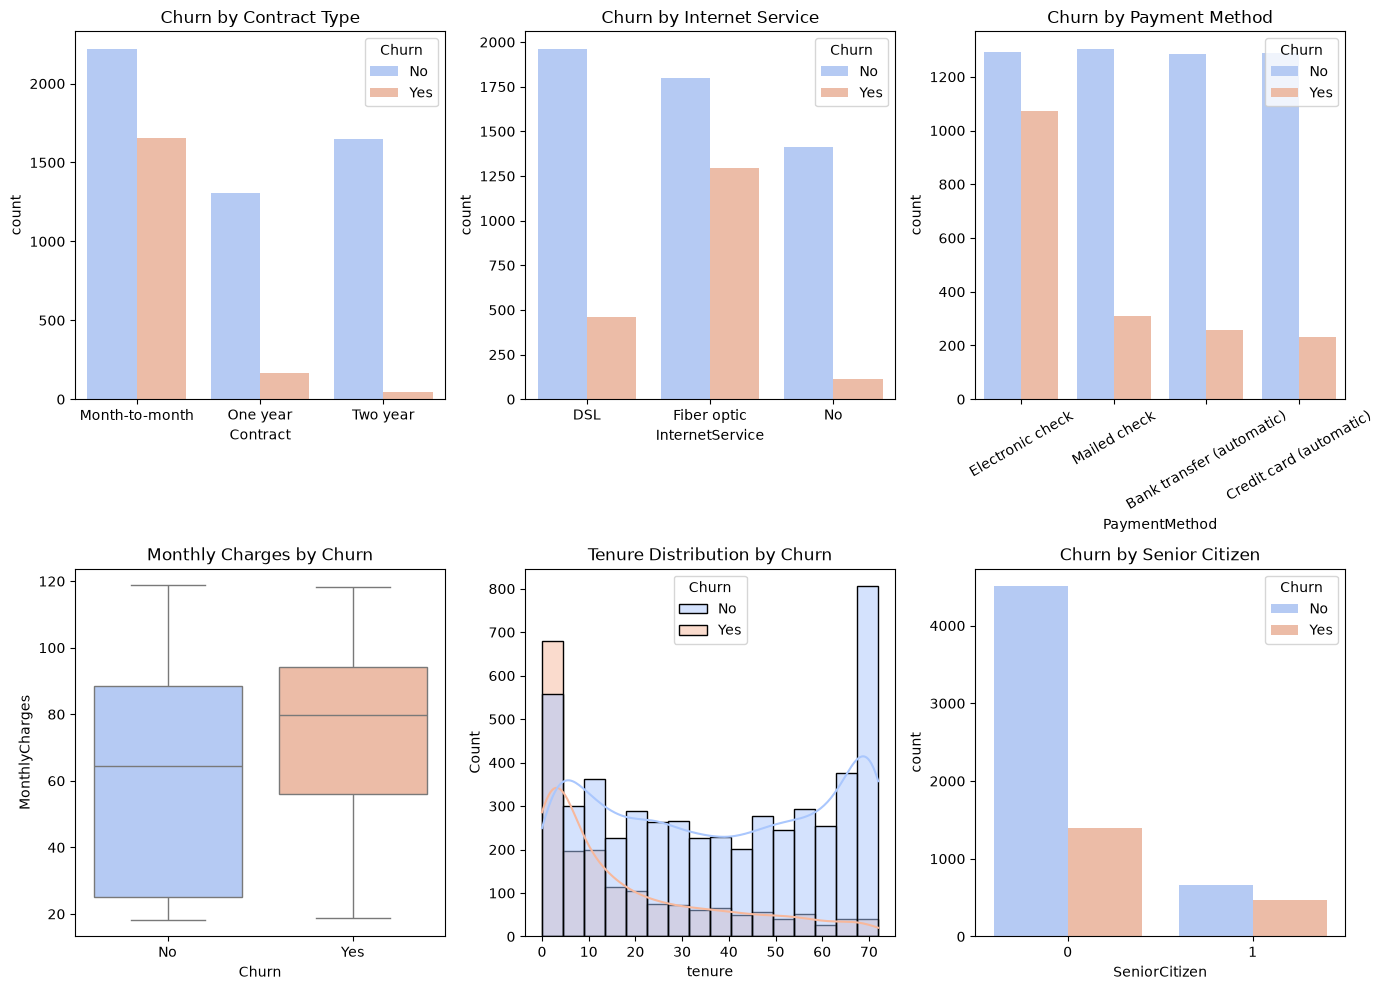

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# Contract type
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0,0], palette='coolwarm')
axes[0,0].set_title("Churn by Contract Type")

# Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[0,1], palette='coolwarm')
axes[0,1].set_title("Churn by Internet Service")

# Payment Method
sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[0,2], palette='coolwarm')
axes[0,2].set_title("Churn by Payment Method")
axes[0,2].tick_params(axis='x', rotation=30)

# Monthly Charges
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1,0], palette='coolwarm')
axes[1,0].set_title("Monthly Charges by Churn")

# Tenure
sns.histplot(x='tenure', hue='Churn', data=df, ax=axes[1,1], palette='coolwarm', kde=True)
axes[1,1].set_title("Tenure Distribution by Churn")

# Senior Citizen
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, ax=axes[1,2], palette='coolwarm')
axes[1,2].set_title("Churn by Senior Citizen")

plt.tight_layout()
plt.show()

In [7]:
# Quick stats for churned vs non-churned
churn_summary = df.groupby('Churn').agg({
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': lambda x: pd.to_numeric(x, errors='coerce').mean(),
    'Contract': lambda x: x.mode()[0],
    'InternetService': lambda x: x.mode()[0]
}).round(2)

print("=== Churned vs Not Churned ===")
print(churn_summary)

=== Churned vs Not Churned ===
       tenure  MonthlyCharges  TotalCharges        Contract InternetService
Churn                                                                      
No      37.57           61.27       2555.34  Month-to-month             DSL
Yes     17.98           74.44       1531.80  Month-to-month     Fiber optic
